Data ingelezen: 96 tijdstappen (24 uur, dt = 0.25 h)
Prijs range: 0.0023 .. 0.0592 EUR/kWh
Koelvraag range: 79.4 .. 105.7 kW
PV range: 0.0 .. 42.3 kW

Optimalisatie status: optimal
Optimale netto kosten (MET optimalisatie): 98.25 EUR
Totale kosten ZONDER optimalisatie (referentie): 98.73 EUR

RESULTATENOVERZICHT
Kosten ZONDER optimalisatie :      98.73 EUR
Kosten MET optimalisatie    :      98.25 EUR
Besparing                   :       0.48 EUR  (0.5 %)


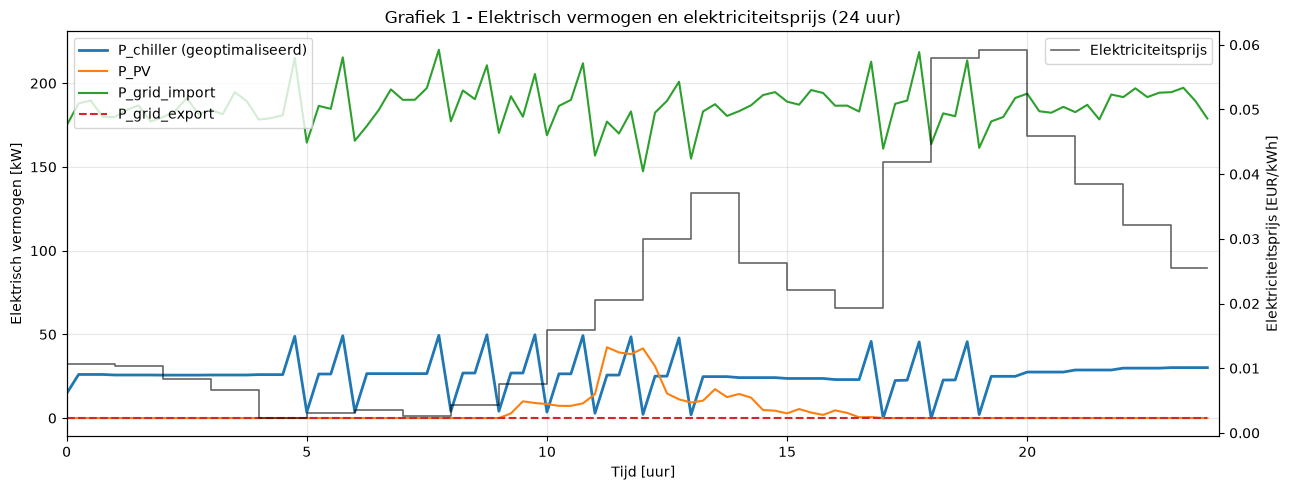

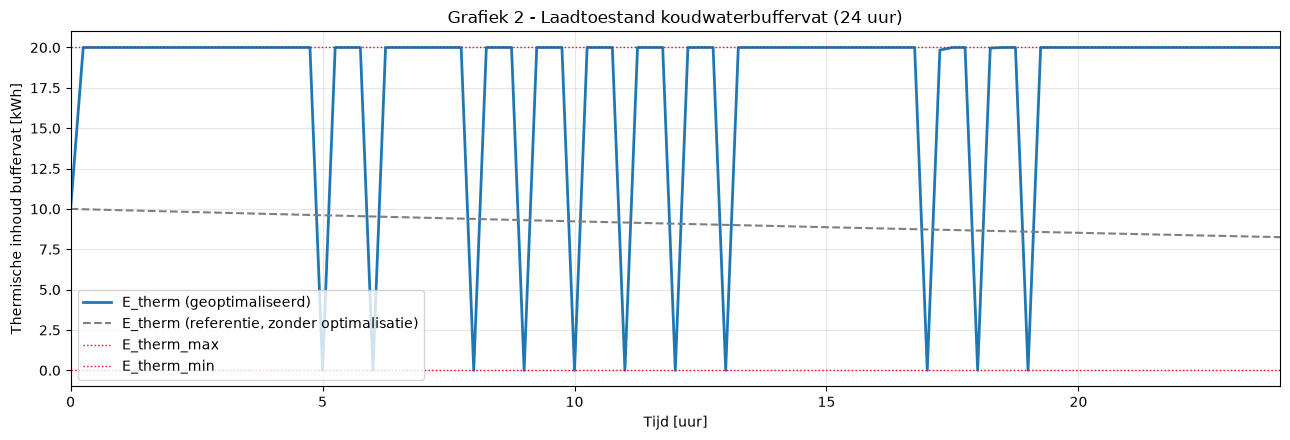


Grafieken opgeslagen als 'grafiek1_vermogen_prijs.png' en 'grafiek2_buffervat.png'.


In [4]:
"""
Optimalisatie van chiller-aansturing met koudwaterbuffervat (24 uur, kwartierresolutie)
=========================================================================================

Doel:
    Minimaliseer de netto elektriciteitskosten van een fabriek door het elektrisch
    vermogen van een chiller (met koudwaterbuffervat) slim te sturen, rekening
    houdend met de elektriciteitsprijs, PV-productie en niet-flexibele belasting.

Auteur: Energiemanagement / CVXPY optimalisatie
"""

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA INLEZEN EN VOORBEREIDEN
# =============================================================================

CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

# Tijdstap
dt = 0.25  # uur

# Prijs staat in EUR/MWh in plant1.csv -> omrekenen naar EUR/kWh
price = df["price"].values / 1000.0          # [EUR/kWh]
P_pv = df["pv_production"].values            # [kW]
P_inflex = df["inflex_load"].values           # [kW]
Q_demand = df["thermal_load"].values          # [kW] koelvraag van de machines

time_h = np.arange(N_STEPS) * dt              # tijdas in uren (0 .. 23.75)

print(f"Data ingelezen: {N_STEPS} tijdstappen (24 uur, dt = {dt} h)")
print(f"Prijs range: {price.min():.4f} .. {price.max():.4f} EUR/kWh")
print(f"Koelvraag range: {Q_demand.min():.1f} .. {Q_demand.max():.1f} kW")
print(f"PV range: {P_pv.min():.1f} .. {P_pv.max():.1f} kW")

# =============================================================================
# 2. PARAMETERS
# =============================================================================

# --- Chiller ---
P_max_chiller = 250.0      # kW elektrisch, maximaal vermogen chiller
EER_chiller = 3.5          # Energy Efficiency Ratio (vast)

# --- Buffervat (~2.5 m3 water, 6-12 C rond 10 C) ---
E_therm_max = 20.0         # kWh, maximale thermische inhoud
E_therm_min = 0.0          # kWh, minimale thermische inhoud
E_therm_0 = 10.0           # kWh, startwaarde op t=0 (50% geladen)
eta_loss = 0.998           # stilstandsverlies-efficiëntie per tijdstap

# =============================================================================
# 3. OPTIMALISATIEMODEL (CVXPY)
# =============================================================================

# --- Beslissingsvariabelen ---
P_chiller = cp.Variable(N_STEPS, nonneg=True)      # elektrisch vermogen chiller [kW]
P_grid_import = cp.Variable(N_STEPS, nonneg=True)  # vermogen afgenomen van net [kW]
P_grid_export = cp.Variable(N_STEPS, nonneg=True)  # vermogen geinjecteerd op net [kW]
E_therm = cp.Variable(N_STEPS + 1)                 # thermische inhoud buffervat [kWh]
                                                     # (N_STEPS+1: incl. eindwaarde na laatste stap)

Q_chiller = EER_chiller * P_chiller                # thermisch koelvermogen chiller [kW]

constraints = []

# Chiller vermogenslimiet
constraints += [P_chiller <= P_max_chiller]

# Startwaarde buffervat
constraints += [E_therm[0] == E_therm_0]

# Thermische balans buffervat:
#   E[t+1] = eta_loss * E[t] + (-Q_chiller[t] + Q_demand[t]) * dt
# Koelen (Q_chiller) verlaagt E_therm; koelvraag en verliezen verhogen E_therm.
for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1] == eta_loss * E_therm[t] + (-Q_chiller[t] + Q_demand[t]) * dt
    ]

# Buffervat grenzen (voor alle tijdstappen inclusief eindwaarde)
constraints += [E_therm >= E_therm_min, E_therm <= E_therm_max]

# Elektrische netbalans per tijdstap:
#   P_PV + P_grid_import = P_chiller + P_inflex + P_grid_export
constraints += [
    P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export
]

# --- Doelfunctie: minimaliseer netto elektriciteitskosten ---
objective = cp.Minimize(
    cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
)

problem = cp.Problem(objective, constraints)
result = problem.solve(solver=cp.HIGHS)

print(f"\nOptimalisatie status: {problem.status}")
print(f"Optimale netto kosten (MET optimalisatie): {result:.2f} EUR")

# =============================================================================
# 4. REFERENTIESCENARIO: CHILLER VOLGT DIRECT DE KOELVRAAG (ZONDER OPTIMALISATIE)
# =============================================================================

# P_chiller = Q_demand / EER  (chiller regelt enkel op basis van actuele koelvraag,
# geen gebruik van buffercapaciteit om te verschuiven in tijd)
P_chiller_ref = np.clip(Q_demand / EER_chiller, 0, P_max_chiller)

# Elektrische netbalans oplossen voor import/export (geen keuzevrijheid meer,
# want P_chiller_ref ligt vast -> net-uitwisseling volgt rechtstreeks uit balans)
net_ref = P_chiller_ref + P_inflex - P_pv           # kW, positief = netto afname
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.clip(-net_ref, 0, None)

cost_ref = np.sum((P_grid_import_ref - P_grid_export_ref) * price * dt)

# Ter info: thermische toestand van het buffervat in het referentiescenario
E_therm_ref = np.zeros(N_STEPS + 1)
E_therm_ref[0] = E_therm_0
for t in range(N_STEPS):
    E_therm_ref[t + 1] = (eta_loss * E_therm_ref[t]
                           + (-EER_chiller * P_chiller_ref[t] + Q_demand[t]) * dt)

print(f"Totale kosten ZONDER optimalisatie (referentie): {cost_ref:.2f} EUR")

# =============================================================================
# 5. RESULTATEN & BESPARING
# =============================================================================

cost_opt = result
saving_eur = cost_ref - cost_opt
saving_pct = 100 * saving_eur / cost_ref if cost_ref != 0 else np.nan

print("\n" + "=" * 55)
print("RESULTATENOVERZICHT")
print("=" * 55)
print(f"Kosten ZONDER optimalisatie : {cost_ref:10.2f} EUR")
print(f"Kosten MET optimalisatie    : {cost_opt:10.2f} EUR")
print(f"Besparing                   : {saving_eur:10.2f} EUR  ({saving_pct:.1f} %)")
print("=" * 55)

# Waarden ophalen uit de oplossing
P_chiller_opt = P_chiller.value
P_grid_import_opt = P_grid_import.value
P_grid_export_opt = P_grid_export.value
E_therm_opt = E_therm.value

# =============================================================================
# 6. GRAFIEKEN
# =============================================================================

fig1, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(time_h, P_chiller_opt, label="P_chiller (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax1.plot(time_h, P_pv, label="P_PV", color="tab:orange", linewidth=1.5)
ax1.plot(time_h, P_grid_import_opt, label="P_grid_import", color="tab:green", linewidth=1.5)
ax1.plot(time_h, P_grid_export_opt, label="P_grid_export", color="tab:red", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(time_h, price, where="post", color="black", linewidth=1.2, alpha=0.6, label="Elektriciteitsprijs")
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")

ax1.set_title("Grafiek 1 - Elektrisch vermogen en elektriciteitsprijs (24 uur)")
fig1.tight_layout()
fig1.savefig("grafiek1_vermogen_prijs.png", dpi=150)

fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt  # inclusief eindpunt t=24h

ax2.plot(time_h_full, E_therm_opt, label="E_therm (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax2.plot(time_h_full, E_therm_ref, label="E_therm (referentie, zonder optimalisatie)",
         color="tab:gray", linewidth=1.5, linestyle="--")
ax2.axhline(E_therm_max, color="red", linestyle=":", linewidth=1, label="E_therm_max")
ax2.axhline(E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min")
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, E_therm_max + 1)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title("Grafiek 2 - Laadtoestand koudwaterbuffervat (24 uur)")
fig2.tight_layout()
fig2.savefig("grafiek2_buffervat.png", dpi=150)

plt.show()

print("\nGrafieken opgeslagen als 'grafiek1_vermogen_prijs.png' en 'grafiek2_buffervat.png'.")